<a href="https://colab.research.google.com/github/WyGhoST/NLP-WyGhoST_Lab/blob/main/lap5/Tran_Quoc_Huy_2411283_homelab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install gensim
!pip install gensim --upgrade
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.1 MB/s eta 0:00:00


Dataset được upload lên GitHub và tải về bằng wget thông qua đường dẫn raw. Cách làm này giúp notebook không phụ thuộc vào file trong máy cá nhân, đảm bảo có thể chạy lại ở mọi môi trường (Colab, Kaggle, Jupyter) và đáp ứng yêu cầu bài tập là xử lý cả bước tải dữ liệu trong cùng một file notebook.

In [3]:
!wget -O Online_Retail.xlsx "https://raw.githubusercontent.com/WyGhoST/NLP-WyGhoST_Lab/main/lap5/Online%20Retail.xlsx"
import pandas as pd
df = pd.read_excel("Online_Retail.xlsx")
df.head()

--2026-03-04 07:40:09--  https://raw.githubusercontent.com/WyGhoST/NLP-WyGhoST_Lab/main/lap5/Online%20Retail.xlsx
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23715344 (23M) [application/octet-stream]
Saving to: ‘Online_Retail.xlsx’

Online_Retail.xlsx  100%[===================>]  22.62M  --.-KB/s    in 0.07s   

2026-03-04 07:40:09 (315 MB/s) - ‘Online_Retail.xlsx’ saved [23715344/23715344]



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape, df.columns
df = df[['InvoiceNo', 'Description']]
df.head()

,InvoiceNo,Description
0,536365,WHITE HANGING HEART T-LIGHT HOLDER
1,536365,WHITE METAL LANTERN
2,536365,CREAM CUPID HEARTS COAT HANGER
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE
4,536365,RED WOOLLY HOTTIE WHITE HEART.


In [5]:
# drop missing
df = df.dropna(subset=['InvoiceNo', 'Description'])

# chuẩn hóa tên sản phẩm
df['Description'] = df['Description'].astype(str).str.strip()

# mỗi InvoiceNo là 1 "giỏ hàng" (sentence)
transactions = df.groupby('InvoiceNo')['Description'].apply(list).tolist()

print("Number of transactions:", len(transactions))
print("Example transaction:", transactions[0][:10])

Number of transactions: 24446
Example transaction: ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.', 'SET 7 BABUSHKA NESTING BOXES', 'GLASS STAR FROSTED T-LIGHT HOLDER']


In [6]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    transactions,
    test_size=0.1,
    random_state=42
)

print("Train size:", len(train_data))
print("Test size:", len(test_data))

Train size: 22001
Test size: 2445


In [7]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=train_data,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1
)

print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 3510


In [8]:
def recommend_similar_products(model, product_name, topn=10):
    if product_name not in model.wv:
        return f"'{product_name}' not in vocabulary!"
    return model.wv.most_similar(product_name, topn=topn)

In [9]:
sample_product = w2v_model.wv.index_to_key[0]
print("Sample product:", sample_product)

recommend_similar_products(w2v_model, sample_product, topn=5)

Sample product: WHITE HANGING HEART T-LIGHT HOLDER


[('CREAM HANGING HEART T-LIGHT HOLDER', 0.5942322015762329),
 ('PEARL CRYSTAL PUMPKIN T-LIGHT HLDR', 0.5756329298019409),
 ('CREAM SWEETHEART MINI CHEST', 0.55923992395401),
 ('FRENCH ENAMEL CANDLEHOLDER', 0.5337599515914917),
 ('LADIES & GENTLEMEN METAL SIGN', 0.5335900187492371)]

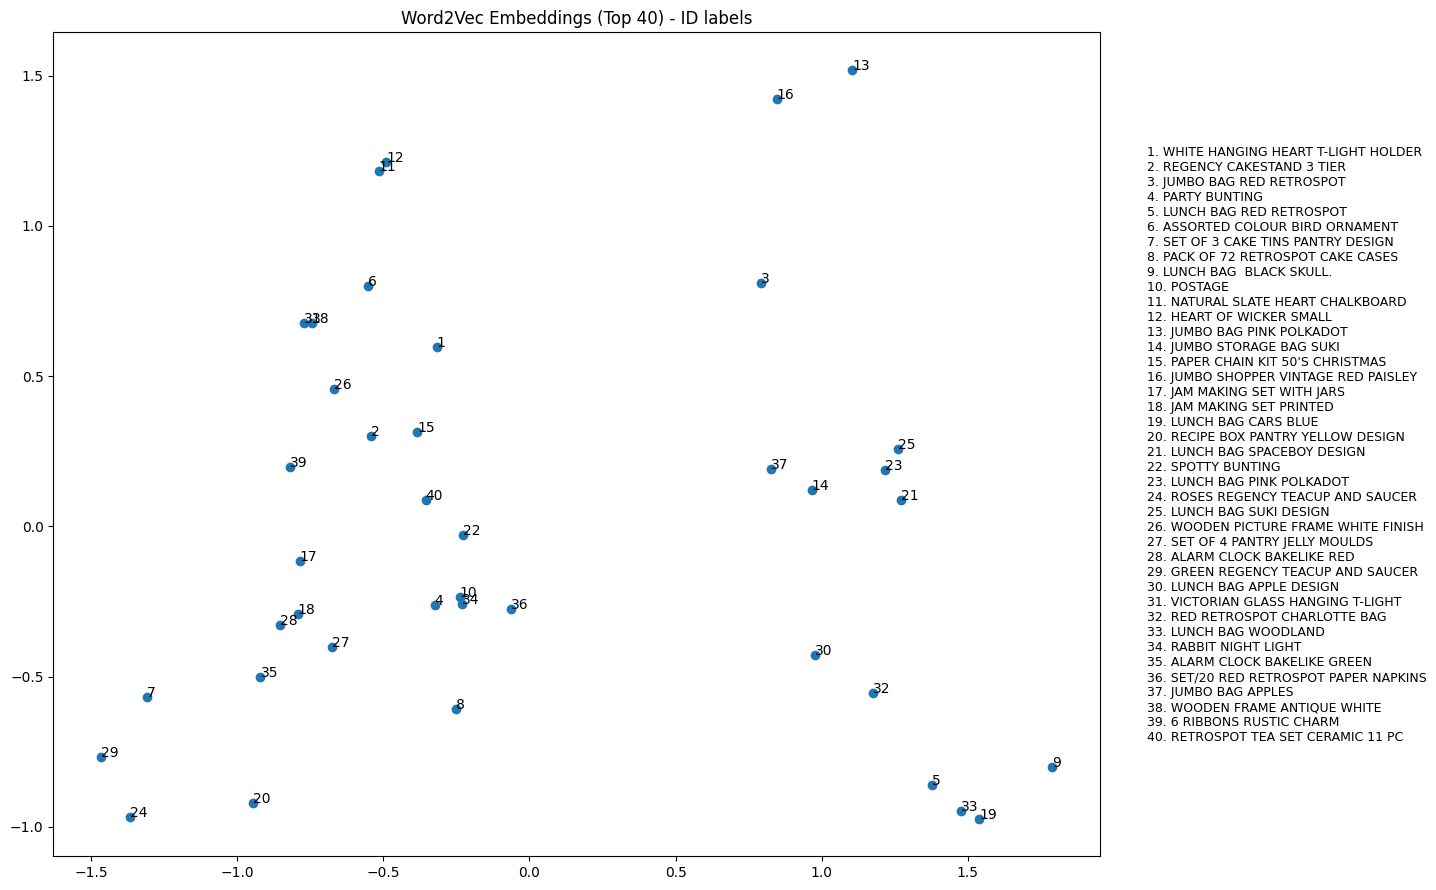

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_embeddings_with_ids(model, topn=40):
    # lấy topn sản phẩm
    words = model.wv.index_to_key[:topn]
    vectors = np.array([model.wv[w] for w in words])

    # PCA 2D
    pca = PCA(n_components=2)
    vec_2d = pca.fit_transform(vectors)

    # vẽ plot
    plt.figure(figsize=(16, 9))
    plt.scatter(vec_2d[:, 0], vec_2d[:, 1])

    # đánh số ID tại từng điểm
    for i, (x, y) in enumerate(vec_2d, start=1):
        plt.text(x, y, str(i), fontsize=10)

    plt.title(f"Word2Vec Embeddings (Top {topn}) - ID labels")

    # tạo chú thích bên phải
    mapping_text = "\n".join([f"{i+1}. {w}" for i, w in enumerate(words)])
    plt.gcf().text(0.72, 0.5, mapping_text, fontsize=9, va='center')

    # chừa khoảng trống bên phải cho chú thích
    plt.tight_layout(rect=[0, 0, 0.7, 1])
    plt.show()

# chạy
plot_embeddings_with_ids(w2v_model, topn=40)

In [11]:
def recommend_for_customer(model, customer_products, topn=10):
    # lọc các sản phẩm có trong vocab
    valid = [p for p in customer_products if p in model.wv]
    if len(valid) == 0:
        return "None of the customer products are in vocabulary!"

    user_vec = np.mean([model.wv[p] for p in valid], axis=0)

    # gợi ý topn sản phẩm gần user vector
    recs = model.wv.similar_by_vector(user_vec, topn=topn)

    # loại bỏ sản phẩm đã mua khỏi gợi ý
    recs = [r for r in recs if r[0] not in set(valid)]
    return recs[:topn]

In [12]:
customer_history = train_data[0][:5]
print("Customer bought:", customer_history)

recommend_for_customer(w2v_model, customer_history, topn=10)

Customer bought: ['POSTAGE', 'PINK HAPPY BIRTHDAY BUNTING']


[('BLUE HAPPY BIRTHDAY BUNTING', 0.7853644490242004),
 ('PINK PARTY BAGS', 0.717459499835968),
 ('BLUE PARTY BAGS', 0.7084974646568298),
 ('PARTY CONES CANDY ASSORTED', 0.6779109835624695),
 ('BIRDS MOBILE VINTAGE DESIGN', 0.6695900559425354),
 ('RETROSPOT PARTY BAG + STICKER SET', 0.6473243236541748),
 ('DINOSAUR PARTY BAG + STICKER SET', 0.6456161737442017),
 ('BLUE TABLE RUN FLOWER', 0.6450856328010559)]